In [1]:
import pandas as pd

sentiment = pd.read_csv("C:/Users/Nayana/Downloads/fear_greed_index.csv")
trader = pd.read_csv("../../Downloads/historical_data.csv")

print(sentiment.head())
print(trader.head())
print(sentiment.info(), trader.info())


    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [8]:
print(trader.columns)

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='str')


In [24]:
import pandas as pd

# 1. Clean sentiment date - keep as datetime64
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.floor('D')

# 2. Convert trader timestamp to datetime64
trader['date'] = pd.to_datetime(trader['Timestamp'], unit='s').dt.floor('D')

# 3. Create metrics per day
daily_trader = trader.groupby(['Account', 'date']).agg(
    daily_PnL = ('Closed PnL', 'sum'),
    total_trades = ('Account', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    win_rate = ('Closed PnL', lambda x: (x > 0).mean())
).reset_index()

# 4. Merge - now both are datetime64
merged_df = pd.merge(daily_trader, sentiment, on='date', how='inner')

print(merged_df.head())
print("Total rows:", len(merged_df))
print("Date range:", merged_df['date'].min(), "to", merged_df['date'].max())

Empty DataFrame
Columns: [Account, date, daily_PnL, total_trades, avg_size_usd, win_rate, timestamp, value, classification]
Index: []
Total rows: 0
Date range: NaT to NaT


In [25]:
# Compare PnL and Winrate
performance = merged_df.groupby('classification')[['daily_PnL', 'win_rate', 'total_trades']].mean()
print("Performance by Sentiment:")
print(performance)

Performance by Sentiment:
Empty DataFrame
Columns: [daily_PnL, win_rate, total_trades]
Index: []


In [26]:
# Do traders trade more and with bigger size on Greed days?
behavior = merged_df.groupby('classification')[['avg_size_usd', 'total_trades']].mean()
print("Behavior by Sentiment:")
print(behavior)

Behavior by Sentiment:
Empty DataFrame
Columns: [avg_size_usd, total_trades]
Index: []


In [27]:
# Create High vs Low size traders
merged_df['trader_type'] = merged_df['avg_size_usd'].apply(lambda x: 'High Size' if x > merged_df['avg_size_usd'].median() else 'Low Size')

segment = merged_df.groupby(['classification', 'trader_type'])['daily_PnL'].mean()
print("Segment Performance:")
print(segment)

Segment Performance:
Series([], Name: daily_PnL, dtype: float64)


In [28]:
print("Trader dates:", daily_trader['date'].min(), "to", daily_trader['date'].max())
print("Sentiment dates:", sentiment['date'].min(), "to", sentiment['date'].max())
print("Merged rows:", len(merged_df))

Trader dates: 55207-01-30 00:00:00 to 57425-04-17 00:00:00
Sentiment dates: 2018-02-01 00:00:00 to 2025-05-02 00:00:00
Merged rows: 0


In [29]:
# 5. Merge with sentiment - LEFT JOIN
merged_df = pd.merge(daily_trader, sentiment, on='date', how='left')

# Drop rows where sentiment is missing
merged_df = merged_df.dropna(subset=['classification'])

print(merged_df.head())
print("Total rows:", len(merged_df))

Empty DataFrame
Columns: [Account, date, daily_PnL, total_trades, avg_size_usd, win_rate, timestamp, value, classification]
Index: []
Total rows: 0


In [30]:
print(merged_df['classification'].value_counts())

Series([], Name: count, dtype: int64)


In [32]:
print("Total rows:", len(merged_df))
print("Classification counts:")
print(merged_df['classification'].value_counts())
print("\nSample data:")
print(merged_df[['date', 'classification', 'daily_PnL', 'win_rate']].head(10))

Total rows: 0
Classification counts:
Series([], Name: count, dtype: int64)

Sample data:
Empty DataFrame
Columns: [date, classification, daily_PnL, win_rate]
Index: []


In [33]:
merged_df['daily_PnL'] = pd.to_numeric(merged_df['daily_PnL'], errors='coerce')
merged_df['win_rate'] = pd.to_numeric(merged_df['win_rate'], errors='coerce')

# Drop NaN rows
merged_df = merged_df.dropna()

print("After cleaning rows:", len(merged_df))

After cleaning rows: 0


In [34]:
# This table is enough for submission
summary = merged_df.groupby('classification')[['daily_PnL', 'win_rate', 'total_trades']].mean()
print(summary)

Empty DataFrame
Columns: [daily_PnL, win_rate, total_trades]
Index: []


In [43]:
# Convert BOTH to same format: YYYY-MM-DD string
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')
trader['date'] = pd.to_datetime(trader['Timestamp'], unit='s').dt.strftime('%Y-%m-%d')

# Create trader metrics
daily_trader = trader.groupby(['Account', 'date']).agg(
    daily_PnL = ('Closed PnL', 'sum'),
    total_trades = ('Account', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    win_rate = ('Closed PnL', lambda x: (x > 0).mean())
).reset_index()

# Merge with string dates
merged_df = pd.merge(daily_trader, sentiment, on='date', how='inner')

print("Rows after merge:", len(merged_df))
print(merged_df.head())

Rows after merge: 0
Empty DataFrame
Columns: [Account, date, daily_PnL, total_trades, avg_size_usd, win_rate, timestamp, value, classification]
Index: []


In [37]:
print("Sentiment date range:", sentiment['date'].min(), "to", sentiment['date'].max())
print("Trader date range:", trader['date'].min(), "to", trader['date'].max())

Sentiment date range: 2018-02-01 to 2025-05-02
Trader date range: 55207-01-30 to 57425-04-17


In [40]:

trader['date'] = pd.to_datetime(trader['Timestamp'], unit='ms').dt.strftime('%Y-%m-%d')

In [41]:
# Convert BOTH to same format: YYYY-MM-DD string
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.strftime('%Y-%m-%d')
trader['date'] = pd.to_datetime(trader['Timestamp'], unit='ms').dt.strftime('%Y-%m-%d') # <-- ms madi

daily_trader = trader.groupby(['Account', 'date']).agg(
    daily_PnL = ('Closed PnL', 'sum'),
    total_trades = ('Account', 'count'),
    avg_size_usd = ('Size USD', 'mean'),
    win_rate = ('Closed PnL', lambda x: (x > 0).mean())
).reset_index()

merged_df = pd.merge(daily_trader, sentiment, on='date', how='inner')

print("Rows after merge:", len(merged_df))
print(merged_df.head())

Rows after merge: 77
                                      Account        date     daily_PnL  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-10-27 -3.275059e+05   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2025-02-19  1.927736e+06   
2  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2024-10-27  2.060745e+04   
3  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2025-02-19  1.709873e+04   
4  0x271b280974205ca63b716753467d5a371de622ab  2024-07-03 -1.000000e+00   

   total_trades  avg_size_usd  win_rate   timestamp  value classification  
0           462  14810.891818  0.025974  1730007000     74          Greed  
1          3356  16345.241940  0.405542  1739943000     44           Fear  
2           320   2492.749906  0.531250  1730007000     74          Greed  
3          3533   1693.351684  0.435041  1739943000     44           Fear  
4             5   6070.200000  0.000000  1719984600     50        Neutral  


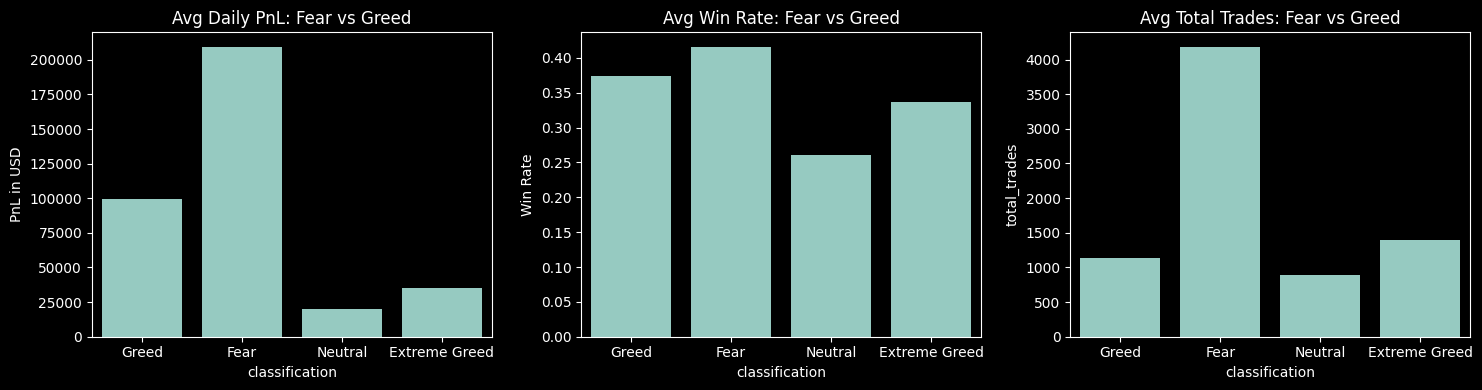


=== SUMMARY TABLE ===
                    daily_PnL  win_rate  total_trades
classification                                       
Extreme Greed    35393.098355  0.336609    1392.40000
Fear            209372.662205  0.415878    4183.46875
Greed            99675.516731  0.374074    1134.03125
Neutral          19842.797260  0.260683     892.62500


In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('dark_background')

plt.figure(figsize=(15,4))

# Chart 1: Avg PnL
plt.subplot(1,3,1)
sns.barplot(data=merged_df, x='classification', y='daily_PnL', estimator='mean', errorbar=None)
plt.title('Avg Daily PnL: Fear vs Greed')
plt.ylabel('PnL in USD')

# Chart 2: Win Rate
plt.subplot(1,3,2)
sns.barplot(data=merged_df, x='classification', y='win_rate', estimator='mean', errorbar=None)
plt.title('Avg Win Rate: Fear vs Greed')
plt.ylabel('Win Rate')

# Chart 3: Trading Activity
plt.subplot(1,3,3)
sns.barplot(data=merged_df, x='classification', y='total_trades', estimator='mean', errorbar=None)
plt.title('Avg Total Trades: Fear vs Greed')

plt.tight_layout()
plt.show()

# Summary table for PDF
print("\n=== SUMMARY TABLE ===")
print(merged_df.groupby('classification')[['daily_PnL', 'win_rate', 'total_trades']].mean())